In [1]:
%matplotlib inline
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import random
import pandas as pd
import itertools
import math
from matplotlib.colors import LogNorm
import time
#from numpy.random import *
import numexpr as ne
from IPython.display import clear_output
import os
import warnings
warnings.filterwarnings('ignore')
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:

import numpy as np

# -------- CTR Model #04 (closed-form) --------
# I(q) = 10**I0 * | sum_{n=0}^{NS} exp(-mu*n) * exp(i*q*aS*n)  +  1/(sqrt(2) * sin(q*a/2)) |^2
# We fix E_KEV (for theta->q conversion), lattice const a, and NS per user request.
E_KEV_FIXED = 8.0           # incident X-ray energy [keV] (fixed)
A_FIXED = 5.43              # lattice constant a [Å] (fixed)
NS_FIXED = 128971           # number of layers (fixed, handled via closed form)

def _geom_series_complex(r, N):
    """Closed form of sum_{n=0}^{N} r^n for complex r."""
    # Avoid numerical issues when r ~ 1
    eps = 1e-12
    near1 = np.abs(r-1) < eps
    out = np.empty_like(r, dtype=np.complex128)
    out[near1] = (N+1) + 0j
    out[~near1] = (1 - np.power(r[~near1], N+1)) / (1 - r[~near1])
    return out

def CTRmodel04(q_data, I0, mu, aS, a=A_FIXED, NS=NS_FIXED):
    # r = exp(-mu) * exp(i q aS)
    r = np.exp(-mu) * np.exp(1j * q_data * aS)
    exp_sum = _geom_series_complex(r, NS)
    # Substrate term
    exp_sum = exp_sum + 1.0 / (np.sqrt(2.0) * np.sin(q_data * a / 2.0))
    Iq_ = (10.0**I0) * np.abs(exp_sum)**2
    return Iq_

# Vectorized helper for parallel-tempering replicas:
def CTR04fit(q, _p_):
    # _p_ shape: (num_temp, num_para) with params [I0, mu, aS]
    I0 = _p_[:,0].reshape(num_temp,1)
    mu = _p_[:,1].reshape(num_temp,1)
    aS = _p_[:,2].reshape(num_temp,1)
    return CTRmodel04(q, I0, mu, aS)


In [3]:
def axbfit(x,_p_):
    _a_ = _p_[:,0].reshape(num_temp,1)
    _b_ = _p_[:,1].reshape(num_temp,1)
    y = axb(x,_a_,_b_)
    return y

In [4]:
# メトロポリス法によるパラメータ更新
def update_param(i,E,n,num_para,sigma_R,x,y,_p_,ratio_p,rslt_p,_rslt_p0_,_rslt_p1_,stepsize_p0,stepsize_p1,
                 _ratio_p_,num_temp,_p_min_,_p_max_,burn_in_length):
    #num_para = np.size(_p_max_)
    # temp=0はprior（事前分布）に基づいてサンプリング
    _p_[0,0] = (_p_max_[0]-_p_min_[0])*np.random.rand()+_p_min_[0]
    _p_[0,1] = (_p_max_[1]-_p_min_[1])*np.random.rand()+_p_min_[1]

    for _ii_ in range(num_para):
        _select_ = np.random.randint(0,num_para,num_temp) #パラメータ間の相関がサンプリングに影響しないようにランダムにパラメータ選択して更新。
        #_select_ = int(_ii_)*np.ones(num_temp,dtype="int8") # 順番にパラメータ更新する場合
        _next_p_ = 1*_p_
        for _j_ in range(1,num_temp):# temp=0は別のサンプリングを行う
            _ratio_p_[num_para*_j_+_select_[_j_]] = np.append(_ratio_p_[num_para*_j_+_select_[_j_]],0)
            if(_select_[_j_]==0):
                _next_p_[_j_,0] += stepsize_p0[_j_]*(2*np.random.rand()-1)
            if(_select_[_j_]==1):
                _next_p_[_j_,1] += stepsize_p1[_j_]*(2*np.random.rand()-1)

        _y_ = axbfit(x,_next_p_)
        next_E = 1/2/n/sigma_R**2*np.linalg.norm(y-(
                 _y_
                 ),axis=1)**2

        prob = np.exp(-n*temp*(next_E-E)) - np.random.rand(num_temp)
        J = np.where(prob>0)
        for _jj_ in J[0]:
            if(_p_min_[_select_[_jj_]]<= _next_p_[_jj_,_select_[_jj_]]<=_p_max_[_select_[_jj_]]):
                _p_[_jj_,_select_[_jj_]] = _next_p_[_jj_,_select_[_jj_]]
                E[_jj_] = next_E[_jj_]
                if(_jj_>0):
                    (_ratio_p_[num_para*_jj_+_select_[_jj_]])[-1] +=1#採択率についての履歴を残す
                if(i>=burn_in_length):
                    ratio_p[_jj_,_select_[_jj_]] += 1#採択率そのもの
        rslt_p[_select_[num_temp-1]] = np.append(rslt_p[_select_[num_temp-1]],_p_[num_temp-1,_select_[num_temp-1]])#最低温の履歴
        for _kk_ in range(1,num_temp):#全レプリカのサンプリング履歴を残す
            if(_select_[_kk_]==0):
                _rslt_p0_[_kk_] = np.append(_rslt_p0_[_kk_],_p_[_kk_,0])
            if(_select_[_kk_]==1):
                _rslt_p1_[_kk_] = np.append(_rslt_p1_[_kk_],_p_[_kk_,1])

    #temp=0は必ず更新
    E[0] = next_E[0]
    ratio_p[0,:] = 0
    _rslt_p0_[0] = np.append(_rslt_p0_[0],_p_[0,0])
    _rslt_p1_[0] = np.append(_rslt_p1_[0],_p_[0,1])

    return E

In [5]:
# 擬似フォークト関数
# ローレンツ関数とガウス関数の幅を別々に設定
def psV(x,mu,w_l,w_g,A,x0):
    y = A*(mu*2/np.pi*w_l/(4*(x-x0)**2+w_l**2)+(1-mu)*np.sqrt(4*np.log(2))/np.sqrt(np.pi)/w_g*np.exp(-4*np.log(2)/w_g**2*(x-x0)**2))
    return y
# ローレンツ関数とガウス関数の幅を共通
#def psV(x,mu,w,A,x0):
#    y = A*(mu*2/np.pi*w/(4*(x-x0)**2+w**2)+(1-mu)*np.sqrt(4*np.log(2))/np.sqrt(np.pi)/w*np.exp(-4*np.log(2)/w**2*(x-x0)**2))
#    return y

In [6]:
def psVfit(x,_p_):
    A1   = _p_[:,0].reshape(num_temp,1)
    mu1  = _p_[:,1].reshape(num_temp,1)
    w_l1 = _p_[:,2].reshape(num_temp,1)
    w_g1 = _p_[:,3].reshape(num_temp,1)
    x1   = _p_[:,4].reshape(num_temp,1)
    A2   = _p_[:,5].reshape(num_temp,1)
    mu2  = _p_[:,6].reshape(num_temp,1)
    w_l2 = _p_[:,7].reshape(num_temp,1)
    w_g2 = _p_[:,8].reshape(num_temp,1)
    x2   = _p_[:,9].reshape(num_temp,1)
    y = psV(x,mu1,w_l1,w_g1,A1,x1) + psV(x,mu2,w_l2,w_g2,A2,x2)
    return y

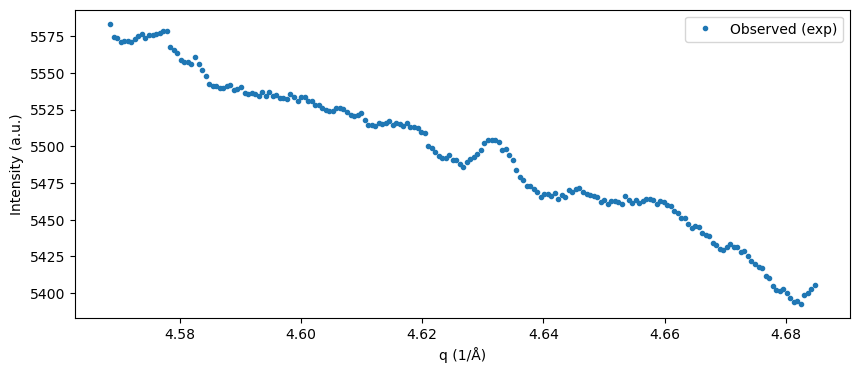

In [7]:

# -------- Load experimental data and convert 2θ to q --------
import pandas as pd, numpy as np, math, os, re

data_path = "data-2025-0822by akai/Si_TEOS_2thome.dat"  # relative path expected by the user
# Robust loader: skip header lines, accept Shift-JIS or others
def load_si_teos(path):
    # Read raw lines
    with open(path, "rb") as f:
        raw = f.read()
    # Decode permissively (file may contain Japanese headers)
    txt = raw.decode("cp932", errors="ignore")
    # Extract rows with numbers separated by commas
    rows = []
    for ln in txt.splitlines():
        if re.match(r"^\s*[-+]?\d+(\.\d+)?\s*,", ln):
            # split by comma
            parts = [p.strip() for p in ln.split(",")]
            try:
                vals = [float(p.replace("E+", "e+").replace("E-", "e-")) for p in parts]
                rows.append(vals)
            except:
                pass
    df = pd.DataFrame(rows)
    # Typical format observed: [2theta_deg, monitor?, intensity, norm]
    # Keep first and third columns when available
    if df.shape[1] >= 3:
        df = df.iloc[:, [0,2]].rename(columns={0:"two_theta_deg", 2:"intensity"})
    else:
        # Fallback: first two as angle & intensity
        df = df.iloc[:, :2]
        df.columns = ["two_theta_deg", "intensity"]
    return df

df = load_si_teos(data_path)

# Physics conversion: E=8 keV -> λ [Å]
lambda_ang = 12.39842 / E_KEV_FIXED
theta_rad = np.deg2rad(df["two_theta_deg"].values / 2.0)
q = (4.0*np.pi/lambda_ang) * np.sin(theta_rad)   # [1/Å]
I_obs = df["intensity"].values.astype(np.float64)

# Guard against singular points in the model (sin term)
mask_good = np.isfinite(I_obs) & np.isfinite(q)
mask_good &= (np.abs(np.sin(q * A_FIXED / 2.0)) > 1e-6)
q = q[mask_good]
I_obs = I_obs[mask_good]

# Keep full measured range (user asked to plot in a suitable range)
x = q.reshape(-1)   # keep variable name 'x' as in the original notebook
y = I_obs.reshape(-1)

# Quick look
plt.figure(figsize=(10,4))
plt.plot(x, y, ".", label="Observed (exp)")
plt.xlabel("q (1/Å)")
plt.ylabel("Intensity (a.u.)")
plt.legend(); plt.show()


In [8]:
x

array([4.56852309, 4.56910765, 4.56969218, 4.57027668, 4.57086114,
       4.57144557, 4.57202996, 4.57261431, 4.57319864, 4.57378292,
       4.57436717, 4.57495139, 4.57553557, 4.57611972, 4.57670383,
       4.57728791, 4.57787195, 4.57845596, 4.57903994, 4.57962387,
       4.58020778, 4.58079165, 4.58137548, 4.58195928, 4.58254304,
       4.58312677, 4.58371047, 4.58429412, 4.58487775, 4.58546134,
       4.58604489, 4.58662841, 4.5872119 , 4.58779535, 4.58837876,
       4.58896214, 4.58954549, 4.59012879, 4.59071207, 4.59129531,
       4.59187851, 4.59246168, 4.59304482, 4.59362792, 4.59421098,
       4.59479401, 4.59537701, 4.59595997, 4.5965429 , 4.59712579,
       4.59770864, 4.59829146, 4.59887425, 4.599457  , 4.60003971,
       4.60062239, 4.60120504, 4.60178765, 4.60237022, 4.60295276,
       4.60353526, 4.60411773, 4.60470017, 4.60528257, 4.60586493,
       4.60644726, 4.60702956, 4.60761182, 4.60819404, 4.60877623,
       4.60935838, 4.6099405 , 4.61052259, 4.61110463, 4.61168

In [9]:
x

array([4.56852309, 4.56910765, 4.56969218, 4.57027668, 4.57086114,
       4.57144557, 4.57202996, 4.57261431, 4.57319864, 4.57378292,
       4.57436717, 4.57495139, 4.57553557, 4.57611972, 4.57670383,
       4.57728791, 4.57787195, 4.57845596, 4.57903994, 4.57962387,
       4.58020778, 4.58079165, 4.58137548, 4.58195928, 4.58254304,
       4.58312677, 4.58371047, 4.58429412, 4.58487775, 4.58546134,
       4.58604489, 4.58662841, 4.5872119 , 4.58779535, 4.58837876,
       4.58896214, 4.58954549, 4.59012879, 4.59071207, 4.59129531,
       4.59187851, 4.59246168, 4.59304482, 4.59362792, 4.59421098,
       4.59479401, 4.59537701, 4.59595997, 4.5965429 , 4.59712579,
       4.59770864, 4.59829146, 4.59887425, 4.599457  , 4.60003971,
       4.60062239, 4.60120504, 4.60178765, 4.60237022, 4.60295276,
       4.60353526, 4.60411773, 4.60470017, 4.60528257, 4.60586493,
       4.60644726, 4.60702956, 4.60761182, 4.60819404, 4.60877623,
       4.60935838, 4.6099405 , 4.61052259, 4.61110463, 4.61168

In [10]:
y

array([5583.4984, 5574.6674, 5574.1265, 5570.9081, 5572.0936, 5571.7961,
       5571.2918, 5573.3303, 5574.9112, 5576.8159, 5573.6067, 5575.9004,
       5575.515 , 5576.5305, 5577.5382, 5578.8051, 5578.3321, 5567.8958,
       5565.6805, 5563.4241, 5558.5524, 5557.1408, 5557.6554, 5556.2646,
       5560.804 , 5556.2429, 5551.9113, 5548.0687, 5542.8179, 5541.3794,
       5541.0013, 5539.769 , 5540.0942, 5540.8208, 5541.7995, 5538.7066,
       5539.2861, 5540.6029, 5536.577 , 5535.4796, 5536.0328, 5535.3524,
       5534.3812, 5537.0812, 5534.4847, 5536.8601, 5534.4087, 5534.8047,
       5532.6114, 5533.1428, 5532.0079, 5535.4036, 5533.8114, 5530.9564,
       5533.9148, 5533.7041, 5531.2155, 5531.0646, 5528.0092, 5528.5095,
       5526.3038, 5524.6498, 5524.4273, 5524.0651, 5526.2197, 5526.1679,
       5525.4963, 5523.5742, 5521.3586, 5520.4033, 5521.5358, 5522.7721,
       5517.7999, 5514.7144, 5514.2863, 5513.8643, 5516.1994, 5515.3398,
       5515.9369, 5517.1302, 5514.6492, 5515.6155, 

In [11]:
y

array([5583.4984, 5574.6674, 5574.1265, 5570.9081, 5572.0936, 5571.7961,
       5571.2918, 5573.3303, 5574.9112, 5576.8159, 5573.6067, 5575.9004,
       5575.515 , 5576.5305, 5577.5382, 5578.8051, 5578.3321, 5567.8958,
       5565.6805, 5563.4241, 5558.5524, 5557.1408, 5557.6554, 5556.2646,
       5560.804 , 5556.2429, 5551.9113, 5548.0687, 5542.8179, 5541.3794,
       5541.0013, 5539.769 , 5540.0942, 5540.8208, 5541.7995, 5538.7066,
       5539.2861, 5540.6029, 5536.577 , 5535.4796, 5536.0328, 5535.3524,
       5534.3812, 5537.0812, 5534.4847, 5536.8601, 5534.4087, 5534.8047,
       5532.6114, 5533.1428, 5532.0079, 5535.4036, 5533.8114, 5530.9564,
       5533.9148, 5533.7041, 5531.2155, 5531.0646, 5528.0092, 5528.5095,
       5526.3038, 5524.6498, 5524.4273, 5524.0651, 5526.2197, 5526.1679,
       5525.4963, 5523.5742, 5521.3586, 5520.4033, 5521.5358, 5522.7721,
       5517.7999, 5514.7144, 5514.2863, 5513.8643, 5516.1994, 5515.3398,
       5515.9369, 5517.1302, 5514.6492, 5515.6155, 

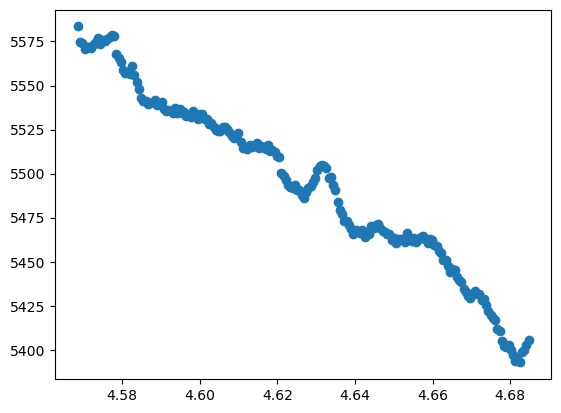

In [12]:
# 解析するデータのプロット
plt.plot(x,y,"o")
plt.show()

In [13]:

# -------- Parallel tempering MCMC (Metropolis) for CTRmodel04 --------
import time, os
np.random.seed(1)

# Parameters: 3 (I0, mu, aS)
num_para = 3

# Prior ranges (Uniform) -- adjust as needed
_p_min_ = np.array([  2.0, 1e-7, 5.00])   # I0, mu, aS
_p_max_ = np.array([  6.0, 1e-3, 6.00])

# Noise std estimate from data (robust): MAD around a smoothed curve
y_med = np.median(y)
sigma_R_sim = max(1e-6, 0.2 * np.std(y))        # fallback
_sigma_R_ = max(1e-6, 0.5 * np.median(np.abs(y - y_med)))  # conservative
sigma_R = _sigma_R_

# Parallel tempering schedule
num_temp = 50
temp = np.logspace(-4, 0, num_temp)  # β from 1e-4 to 1 (temp[0] ~ 1e-4 ... temp[-1] == 1)
temp[0] = 0  # use 0 as "prior-only" chain (as in original)

# Step sizes per parameter, scaled with inverse temperature like original style
_st = np.array([0.05, 1e-5, 5e-3])   # base proposal widths for (I0, mu, aS)
steps = np.zeros((num_temp, num_para))
for j in range(num_para):
    alpha = 5.0
    d = 1.0
    steps[:, j] = np.where(temp <= 1/alpha, _st[j], _st[j] / (alpha*temp)**d)
steps[0, :] = _st  # temp=0 chain

# Initialize from priors if ini_pri==1
ini_pri = 1
if ini_pri == 1:
    _p_ = _p_min_ + (_p_max_ - _p_min_) * np.random.rand(num_temp, num_para)
else:
    _p_ = np.tile((_p_min_ + _p_max_)/2, (num_temp,1))

# Likelihood and energy
def neg_log_like(p, beta, q=x, y=y, sigma=sigma_R):
    # Gaussian log-like scaled by beta (β=1/T)
    yhat = CTRmodel04(q, p[0], p[1], p[2])
    resid = (y - yhat)
    return beta * (0.5 / (sigma**2)) * np.sum(resid*resid)

def neg_log_prior(p):
    # Uniform prior on ranges (0 if in-range else +inf)
    if np.any(p < _p_min_) or np.any(p > _p_max_):
        return np.inf
    return 0.0

def energy(p, beta):
    return neg_log_prior(p) + neg_log_like(p, beta)

# Allocate histories and stats
cycle = 50000
burn_in_length = 10000
n = x.size

_dir_ = "CTR04fit_2025_0827"
os.makedirs(_dir_, exist_ok=True)

ratio_p = np.zeros((num_temp, num_para))   # running accept counts
ratio_temp = np.zeros(num_temp)            # exchange accept counts
mean_E = np.zeros(num_temp)                # running sum of E per chain

# Parameter traces (store a thin version to control size)
rslt_p = [np.array([]) for _ in range(num_para)]          # lowest T traces per parameter (for quick look)
_rslt_p0_ = [np.array([]) for _ in range(num_temp)]       # all chains for param 0
_rslt_p1_ = [np.array([]) for _ in range(num_temp)]       # all chains for param 1
_rslt_p2_ = [np.array([]) for _ in range(num_temp)]       # all chains for param 2

# Per-iteration records for diagnostics (lightweight)
_E_ = np.zeros(num_temp)                 # current energies
for j in range(num_temp):
    _E_[j] = energy(_p_[j], temp[j])

# MCMC loop
st = time.time()
thin = 20

for i in range(cycle):
    # Random-scan updates over parameters
    for _param_idx in np.random.permutation(num_para):
        # Propose for chains j=1..num_temp-1 (j=0 is prior-only refit)
        for j in range(1, num_temp):
            cur = _p_[j].copy()
            prop = cur.copy()
            step = steps[j, _param_idx]
            prop[_param_idx] = cur[_param_idx] + np.random.normal(scale=step)

            # Reflect at bounds to stay within prior range
            low, high = _p_min_[_param_idx], _p_max_[_param_idx]
            if prop[_param_idx] < low or prop[_param_idx] > high:
                prop[_param_idx] = np.clip(low + (low - prop[_param_idx]) if prop[_param_idx] < low else high - (prop[_param_idx]-high), low, high)

            e_cur = _E_[j]
            e_prop = energy(prop, temp[j])
            # Metropolis
            if np.isfinite(e_prop) and (np.random.rand() < np.exp(-(e_prop - e_cur))):
                _p_[j] = prop
                _E_[j] = e_prop
                ratio_p[j, _param_idx] += 1

        # temp=0 chain: draw fresh from prior (prior-only sampling)
        _p_[0, _param_idx] = _p_min_[_param_idx] + (_p_max_[_param_idx]-_p_min_[_param_idx])*np.random.rand()
        _E_[0] = energy(_p_[0], temp[0])

    # Exchange move between neighboring replicas (odd/even)
    if (i % 2) == 0:
        pairs = [(j, j+1) for j in range(1, num_temp-1, 2)]
    else:
        pairs = [(j, j+1) for j in range(2, num_temp-1, 2)]
    for j, k in pairs:
        # Swap with probability min(1, exp(-(E_k(beta_j)+E_j(beta_k) - E_j(beta_j)-E_k(beta_k)) ))
        e_jj = _E_[j]
        e_kk = _E_[k]
        e_jk = energy(_p_[j], temp[k])
        e_kj = energy(_p_[k], temp[j])
        logacc = -(e_jk + e_kj - e_jj - e_kk)
        if np.log(np.random.rand()) < logacc:
            # swap states
            _p_[j], _p_[k] = _p_[k].copy(), _p_[j].copy()
            _E_[j], _E_[k] = _E_[k], _E_[j]
            ratio_temp[j] += 1
            ratio_temp[k] += 1

    # Running sums for diagnostics
    mean_E += _E_

    # Record traces (thin)
    if (i % thin) == 0:
        for j in range(num_temp):
            _rslt_p0_[j] = np.append(_rslt_p0_[j], _p_[j,0])
            _rslt_p1_[j] = np.append(_rslt_p1_[j], _p_[j,1])
            _rslt_p2_[j] = np.append(_rslt_p2_[j], _p_[j,2])
        for pidx in range(num_para):
            rslt_p[pidx] = np.append(rslt_p[pidx], _p_[-1, pidx])  # lowest T chain

    # Periodic checkpoint
    if ((i+1) % 5000) == 0:
        print(i+1, "iters; elapsed", time.time()-st)
        np.save(_dir_+"/ratio_p.npy", ratio_p)
        np.save(_dir_+"/ratio_temp.npy", ratio_temp)
        np.save(_dir_+"/mean_E.npy", mean_E)

        np.save(_dir_+"/_rslt_p0_.npy", _rslt_p0_)
        np.save(_dir_+"/_rslt_p1_.npy", _rslt_p1_)
        np.save(_dir_+"/_rslt_p2_.npy", _rslt_p2_)

        np.save(_dir_+"/_E_.npy", _E_)
        np.save(_dir_+"/_p_all_.npy", _p_)
        np.save(_dir_+"/_mean_E_.npy", mean_E)
        np.save(_dir_+"/_ratio_p_.npy", ratio_p)

# Final save
np.save(_dir_+"/ratio_p.npy", ratio_p)
np.save(_dir_+"/ratio_temp.npy", ratio_temp)
np.save(_dir_+"/mean_E.npy", mean_E)

np.save(_dir_+"/_rslt_p0_.npy", _rslt_p0_)
np.save(_dir_+"/_rslt_p1_.npy", _rslt_p1_)
np.save(_dir_+"/_rslt_p2_.npy", _rslt_p2_)

np.save(_dir_+"/_E_.npy", _E_)
np.save(_dir_+"/_p_all_.npy", _p_)
np.save(_dir_+"/_mean_E_.npy", mean_E)
np.save(_dir_+"/_ratio_p_.npy", ratio_p)

print("Total elapsed:", time.time()-st)


5000 iters; elapsed 57.019015073776245
10000 iters; elapsed 112.85939621925354
15000 iters; elapsed 169.06221652030945
20000 iters; elapsed 224.66958856582642
25000 iters; elapsed 281.6820685863495
30000 iters; elapsed 339.4266846179962
35000 iters; elapsed 398.01841163635254
40000 iters; elapsed 456.37496042251587
45000 iters; elapsed 512.6376526355743
50000 iters; elapsed 568.294408082962
Total elapsed: 568.3092184066772


In [14]:
_dir_

'CTR04fit_2025_0827'

おおむね0.2から0.8の間に収まっていれば成功。


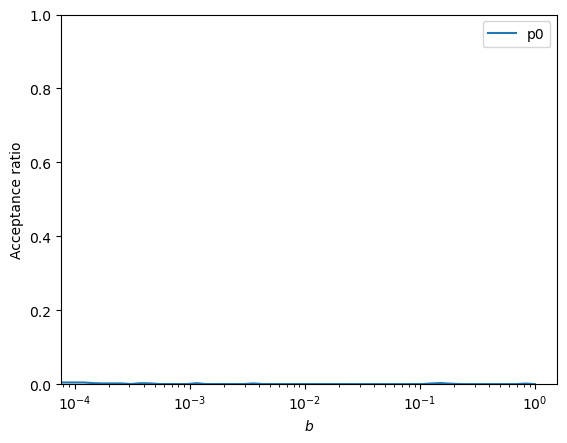

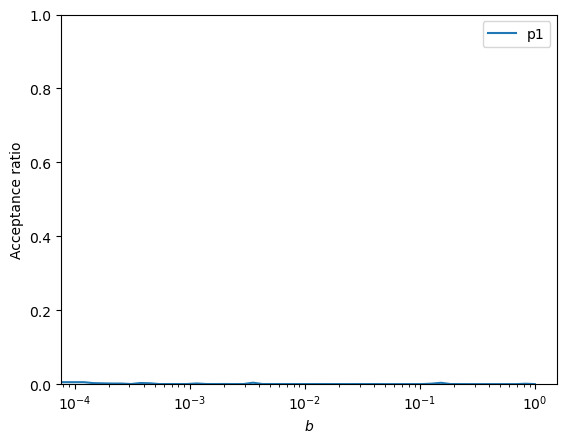

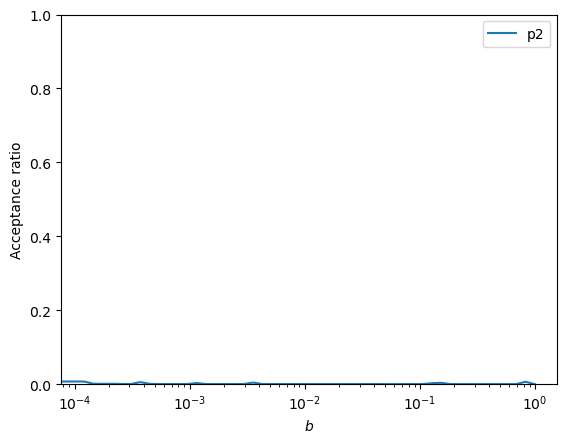

In [15]:
# 採択率のプロット
ratio_p = np.load(_dir_+"/ratio_p.npy")
print("おおむね0.2から0.8の間に収まっていれば成功。")
for i in range(num_para):
    plt.plot(temp,ratio_p[:,i]/(cycle-burn_in_length),label="p{}".format(i))
    plt.xscale("log")
    plt.ylim(0,1)
    plt.xlabel("$b$")
    plt.ylabel("Acceptance ratio")
    plt.legend()
    plt.show()

収束するまでの焼きなまし区間(burn_in)が十分か確認する。


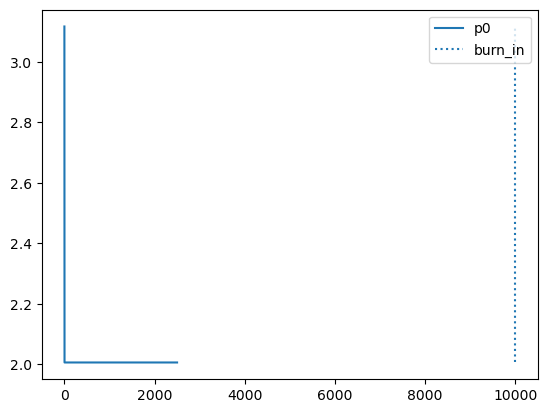

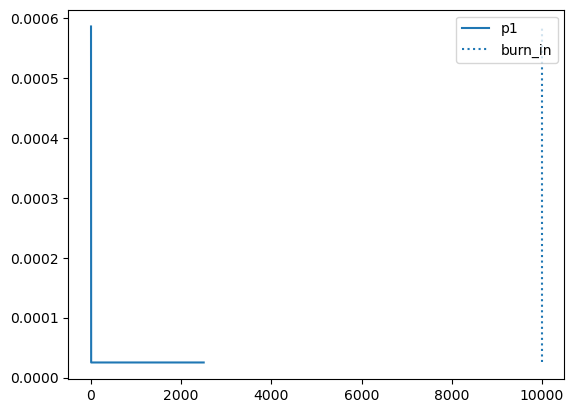

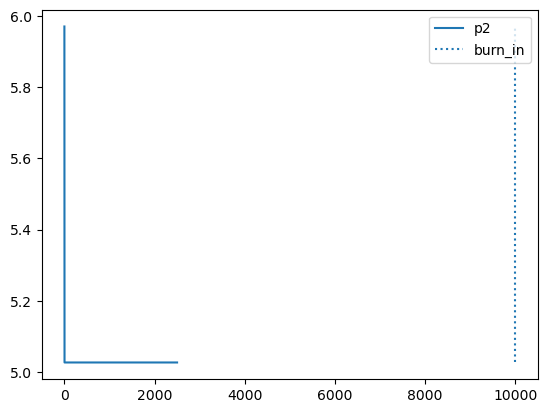

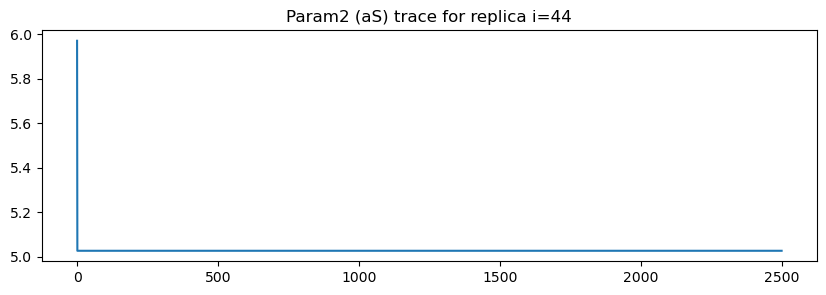

In [16]:
# 各パラメータの採択履歴をプロット
print("収束するまでの焼きなまし区間(burn_in)が十分か確認する。")
i = 44 # 履歴を確認したいレプリカのインデックス（逆温度の数が50の時は0から49までの番号）を入れる
for j in range(num_para):
    _pp_ = np.load(_dir_+"/_rslt_p{}_.npy".format(j), allow_pickle=True)
    plt.plot(_pp_[i],label="p{}".format(j))
    plt.vlines(burn_in_length,np.min(_pp_[i]),np.max(_pp_[i]),label="burn_in",linestyle="dotted")
    plt.legend()
    plt.show()

# 追加: パラメータ2(aS)の履歴を確認
try:
    _rslt_p2_ = np.load(_dir_+"/_rslt_p2_.npy", allow_pickle=True)
    plt.figure(figsize=(10,3))
    plt.plot(_rslt_p2_[i])
    plt.title("Param2 (aS) trace for replica i={}".format(i))
    plt.show()
except Exception as e:
    print("param2 trace plot skipped:", e)


最高温度のレプリカ(b=0)との交換率(右の値がゼロで無いことを確認) 0.0


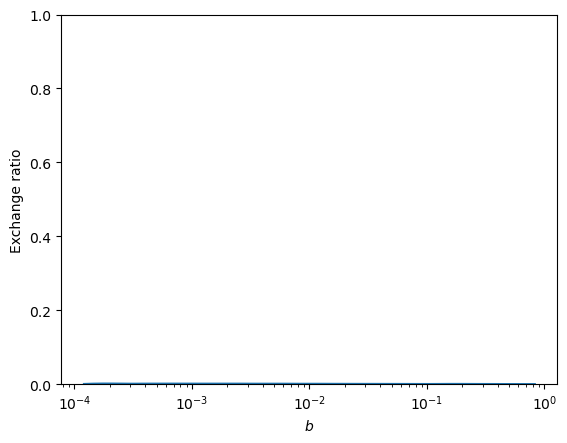

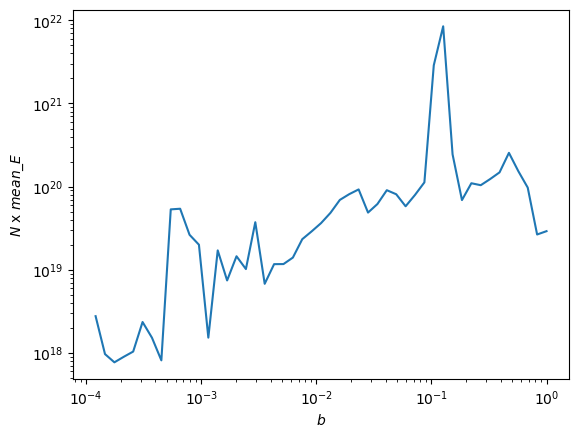

In [17]:
# レプリカ交換率とmean_Eのプロット
ratio_temp = np.load(_dir_+"/ratio_temp.npy")
mean_E = np.load(_dir_+"/mean_E.npy")
print("最高温度のレプリカ(b=0)との交換率(右の値がゼロで無いことを確認)",ratio_temp[0]/((cycle-burn_in_length)/2))
_ratio_temp_ = np.zeros((num_temp,2))
_ratio_temp_[:,0] = 1*temp
_ratio_temp_[:,1] = 1*ratio_temp/((cycle-burn_in_length)/2)
_mean_E_ = np.zeros((num_temp,2))
_mean_E_[:,0] = 1*temp
_mean_E_[:,1] = 1*mean_E/(cycle-burn_in_length)

plt.plot(temp[1:num_temp-1],ratio_temp[1:num_temp-1]/((cycle-burn_in_length)/2))
plt.xscale("log")
plt.xlabel("$b$")
plt.ylabel("Exchange ratio")
plt.ylim(0,1)
plt.show()
plt.plot(temp[1:num_temp],n*mean_E[1:num_temp]/(cycle-burn_in_length))
plt.xlabel("$b$")
plt.xscale("log")
plt.yscale("log")
plt.ylabel("$N$ x $mean$_$E$")
plt.show()

自由エネルギーの最小値 334661811441551.0
推定されたノイズの標準偏差 91.02981779915218
最適な逆温度のインデックス 1


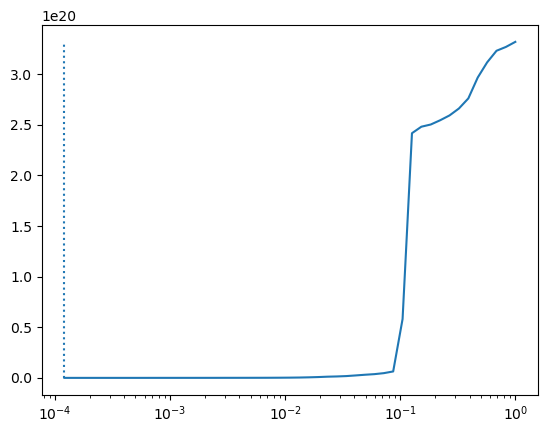

In [18]:
# ノイズ推定
F = []
for i in range(1,num_temp):
    A = 0
    for j in range(i):
        A += (temp[j+1] - temp[j])*mean_E[j+1]/(cycle-burn_in_length)*n
    F = np.append(F,A- n/2*(np.log(temp[i])-np.log(2*np.pi)))
plt.plot(temp[1:num_temp],F)
plt.xscale("log")
plt.vlines(temp[np.argmin(F)+1],np.min(F),np.max(F),linestyle="dotted")
#plt.yscale("log")
#plt.ylim(-200,500)
print("自由エネルギーの最小値",np.min(F))
print("推定されたノイズの標準偏差",1/(temp[np.argmin(F)+1])**0.5)
print("最適な逆温度のインデックス",np.argmin(F)+1)
plt.show()

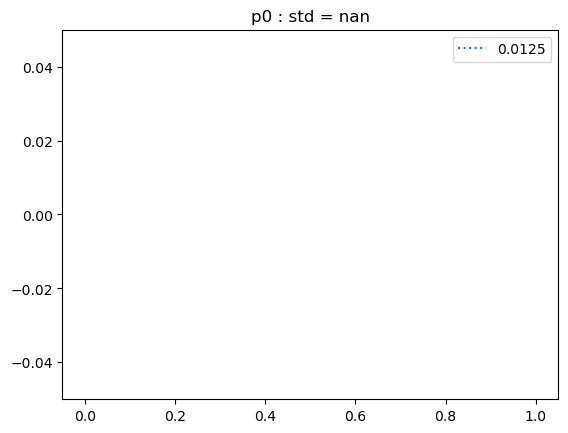

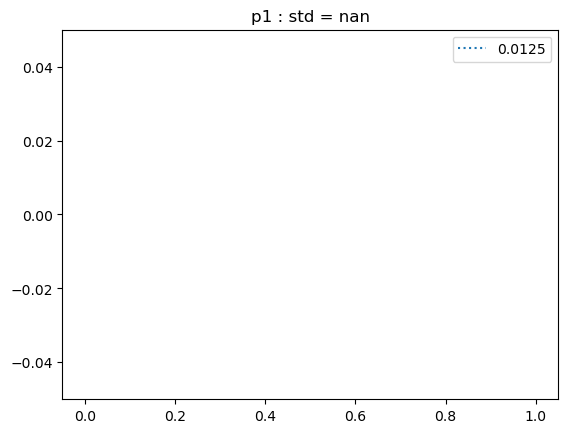

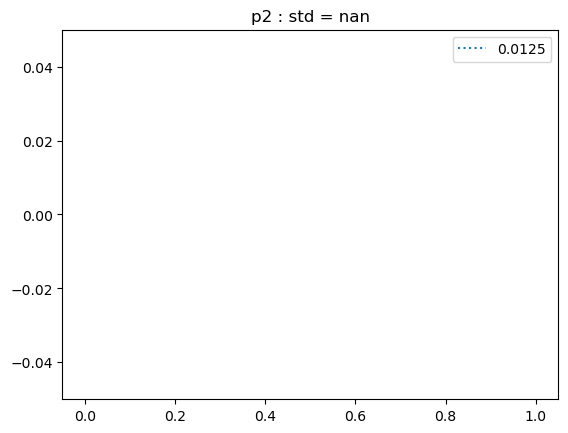

In [19]:

# 事後確率分布をプロット（最低温のレプリカを使用）
i = num_temp-1
_pp_MPM_ = np.zeros(num_para)
for j in range(num_para):
    arr = np.load(_dir_+"/_rslt_p{}_.npy".format(j), allow_pickle=True)
    series = (arr[i])[burn_in_length::]
    plt.title("p{} : std = {:.4f}".format(j, np.std(series)))
    plt.hist(series, bins=40)
    _pp_hist_ = np.histogram(series, bins=40)
    # bin center at maximum
    _pp_MPM_[j] = ((_pp_hist_[1])[np.argmax(_pp_hist_[0])+1] + (_pp_hist_[1])[np.argmax(_pp_hist_[0])]) / 2.0
    plt.vlines(_pp_MPM_[j], 0, 1.1*np.max(_pp_hist_[0]), linestyle="dotted", label="{:.4f}".format(_pp_MPM_[j]))
    plt.ylim(0, 1.1*np.max(_pp_hist_[0]))
    plt.legend()
    plt.show()


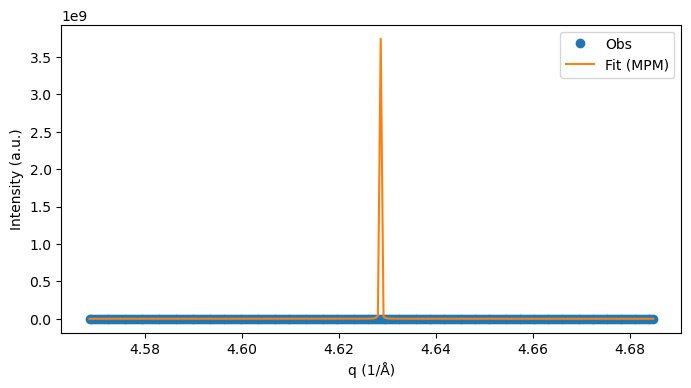

In [20]:

# パラメータごとの事後確率分布の最大値を用いたMPM(maximizer of the posterior marginal)推定によるフィッティング結果
# ここでは最低温のサンプルから各パラメータの中央値をMPM近似として利用
_p_all_ = np.load(_dir_+"/_p_all_.npy")
_pp_MPM_ = np.median(_p_all_[-1:,:], axis=0)  # last row: lowest temperature
I0, mu, aS = _pp_MPM_

y_fit = CTRmodel04(x, I0, mu, aS)

plt.figure(figsize=(8,4))
plt.plot(x, y, "o", label="Obs")
plt.plot(x, y_fit, "-", label="Fit (MPM)")
plt.xlabel("q (1/Å)"); plt.ylabel("Intensity (a.u.)")
plt.legend(); plt.show()


In [21]:
_pp_MPM_

array([2.17820751e+00, 1.02681375e-04, 5.22532711e+00])

In [22]:
# MAP推定
_opt_j_ = np.argmin(F)+1
_pp_MAP_ = np.zeros(num_para)
_optimal_ = np.load(_dir_+"/_optimal_.npy")
for i in range(num_para):
    _pp_MAP_[i] = (_optimal_[num_para*_opt_j_+i])[cycle]
a   = _pp_MAP_[0]
b   = _pp_MAP_[1]
_y_ = axb(x,a,b)

plt.plot(x,y,"o",label="Data")
plt.plot(x,_y_,color="r",label="MAP")
plt.legend()

FileNotFoundError: [Errno 2] No such file or directory: 'CTR04fit_2025_0827/_optimal_.npy'

In [ ]:
_pp_MAP_